## Movie Recommendation

In [203]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import ast
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [204]:
movies = pd.read_csv('../data/movies.csv')
credits = pd.read_csv('../data/credits.csv')

### Datasets

In [205]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [206]:
movies.shape

(4803, 20)

In [207]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [208]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [209]:
credits.shape

(4813, 4)

### Merge datasets

In [210]:
# Use movie_id to merge instead of title for a more reliable join
if 'movie_id' not in movies.columns and 'id' in movies.columns:
    movies = movies.rename(columns={'id': 'movie_id'})
movies['movie_id'] = movies['movie_id'].astype(str)
credits['movie_id'] = credits['movie_id'].astype(str)
movies = movies.merge(credits[['movie_id', 'cast', 'crew']], on='movie_id', how='left')


In [211]:
movies.head()

,budget,genres,homepage,movie_id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [212]:
movies.shape

(4803, 22)

In [213]:
# Select important features for the recommendation system

if 'movie_id' not in movies.columns and 'id' in movies.columns:
    movies = movies.rename(columns={'id': 'movie_id'})

movies = movies[[
    'movie_id',
    'title',
    'overview',
    'genres',
    'keywords',
    'original_language',
    'cast',
    'crew',
    'popularity',
    'vote_average',
    'vote_count',
    'release_date',
    'runtime',
    'revenue'
]]

##### Missing values

In [214]:
missing_counts = movies.isnull().sum()
print('Missing values by column:')
print(missing_counts[missing_counts > 0])

# Drop rows only where important analysis columns are missing
movies.dropna(subset=[
    'title', 'overview', 'genres', 'keywords', 'original_language',
    'cast', 'crew', 'popularity', 'vote_average', 'vote_count',
    'release_date', 'runtime', 'revenue'
], inplace=True)
movies.drop_duplicates(subset='movie_id', inplace=True)
print('After cleanup shape:', movies.shape)


Missing values by column:
overview        3
crew            4
release_date    1
runtime         2
dtype: int64
After cleanup shape: (4795, 14)


In [215]:
movies.describe() # Get summary statistics of the dataset

,popularity,vote_average,vote_count,runtime,revenue
count,4795.000000,4795.000000,4795.000000,4795.000000,4.795000e+03
mean,21.497218,6.093660,690.353702,106.881335,8.220470e+07
std,31.829148,1.188457,1235.081700,22.554451,1.628180e+08
min,0.000372,0.000000,0.000000,0.000000,0.000000e+00
25%,4.681544,5.600000,54.000000,94.000000,0.000000e+00
50%,12.928269,6.200000,235.000000,103.000000,1.917997e+07
75%,28.313505,6.800000,737.000000,117.000000,9.291719e+07
max,875.581305,10.000000,13752.000000,338.000000,2.787965e+09


### EDA (Exploratory Data Analysis)

Distribution of Ratings 

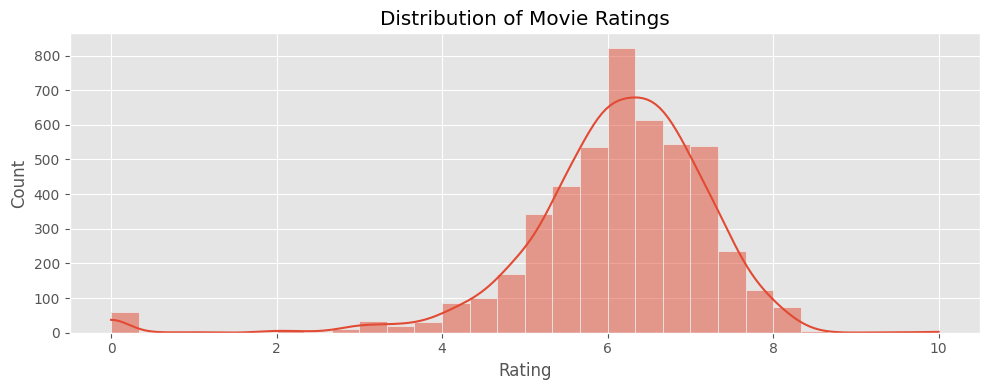

In [216]:
plt.figure(figsize=(10,4))
# ensure numeric and drop missing values
sns.histplot(movies['vote_average'].dropna().astype(float), bins=30, kde=True)

plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Top 10 Most Popular Movies

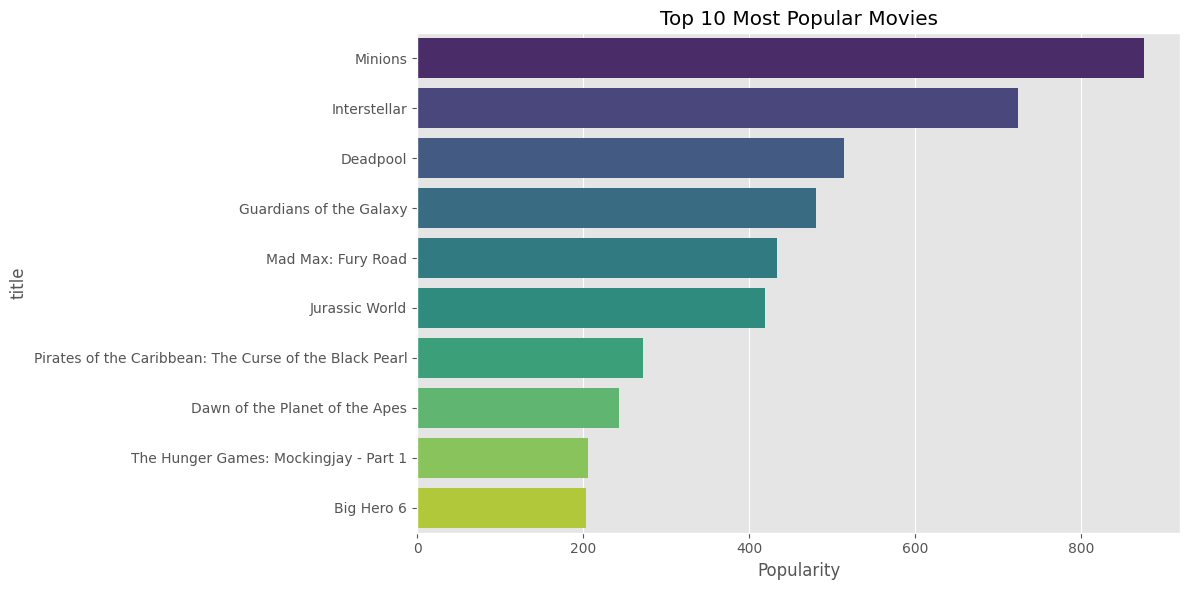

In [217]:
# take top 10 by numeric popularity and plot
top_popular = movies.assign(pop_n=pd.to_numeric(movies['popularity'], errors='coerce')) \
    .sort_values('pop_n', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='pop_n',
    y='title',
    data=top_popular,
    palette='viridis'
)

plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity')
plt.tight_layout()
plt.show()

Revenue Distribution

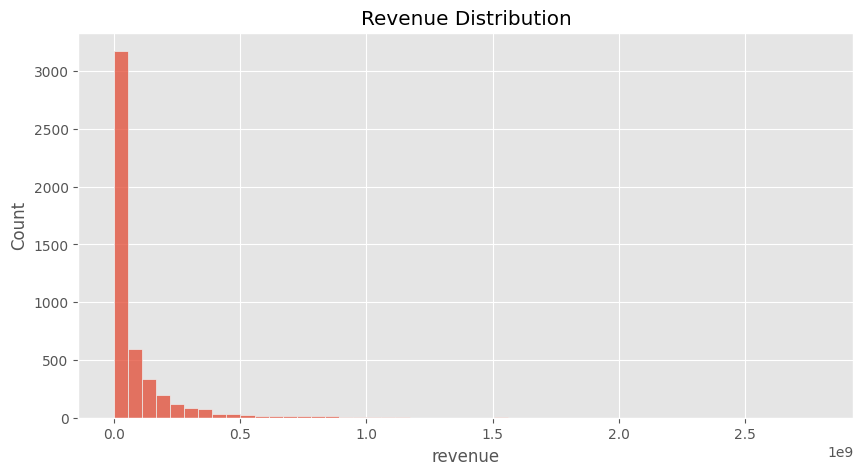

In [218]:
plt.figure(figsize=(10,5))
sns.histplot(movies['revenue'], bins=50)

plt.title('Revenue Distribution')
plt.show()

Runtime Distribution

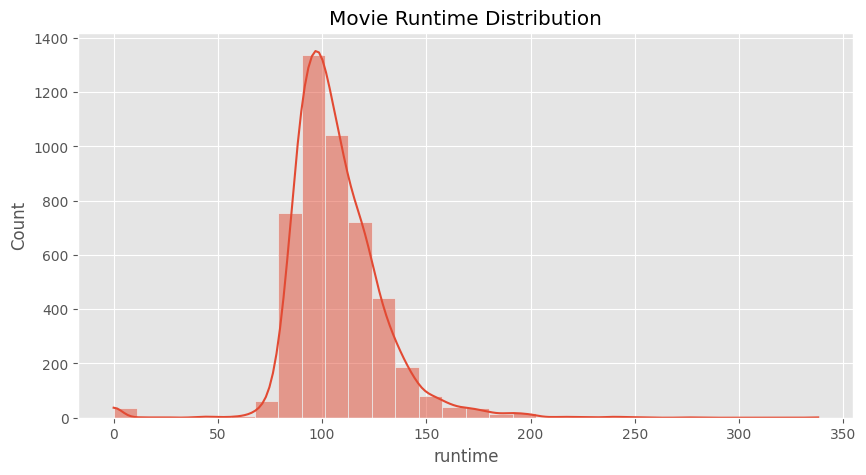

In [219]:
plt.figure(figsize=(10,5))
sns.histplot(movies['runtime'], bins=30, kde=True)

plt.title('Movie Runtime Distribution')
plt.show()

Movies Released per yr

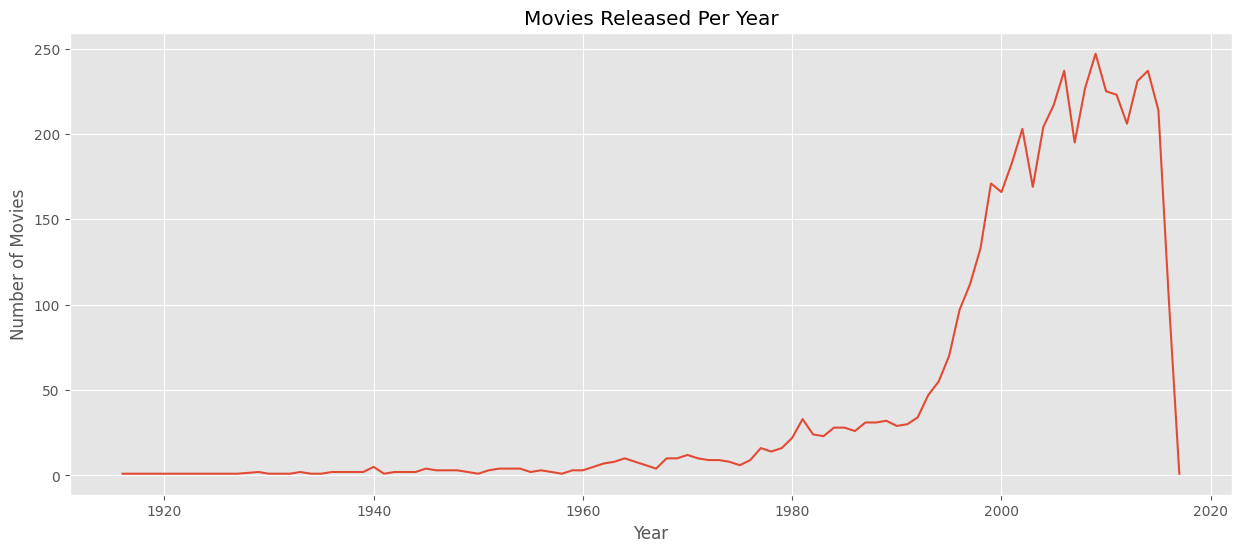

In [220]:
# exract yrs
movies['release_date'] = pd.to_datetime(movies['release_date'])
movies['year'] = movies['release_date'].dt.year

# plot movies per year
movies_per_year = movies['year'].value_counts().sort_index()
plt.figure(figsize=(15,6))

movies_per_year.plot()
plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

Vote Count vs Rating

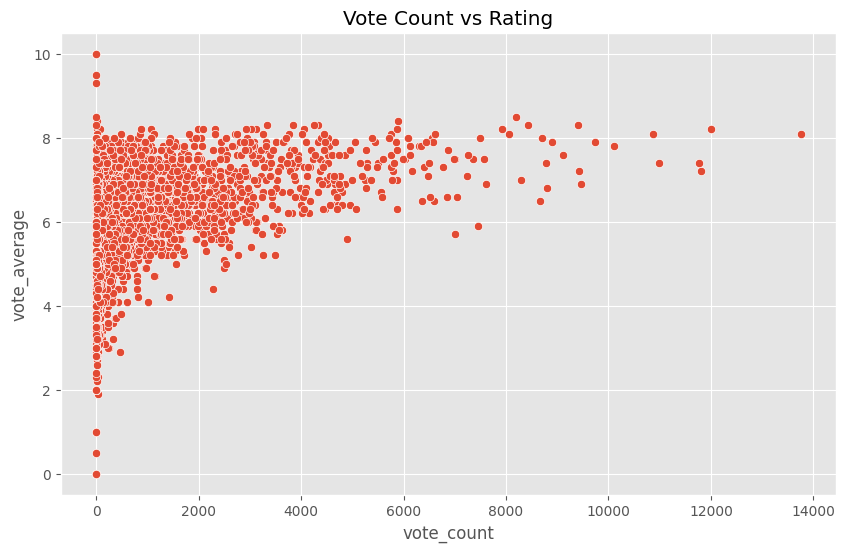

In [221]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='vote_count',
    y='vote_average',
    data=movies
)

plt.title('Vote Count vs Rating')
plt.show()

### Correlation Heatmap

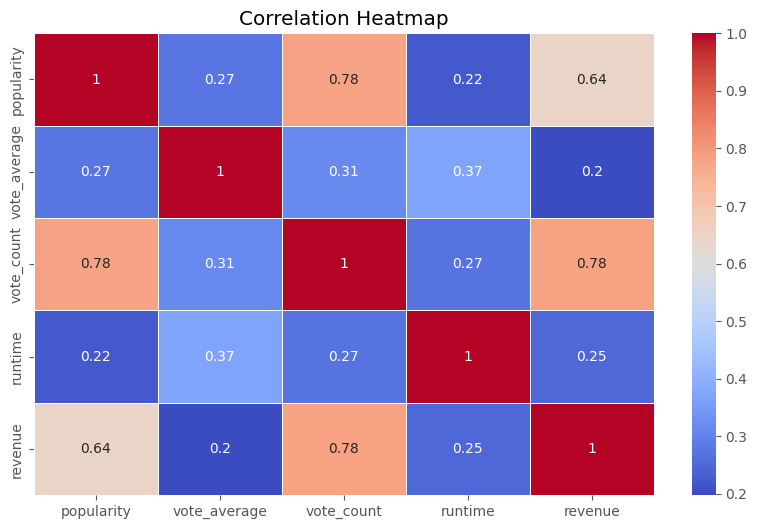

In [222]:
plt.figure(figsize=(10,6))

correlation = movies[
    ['popularity', 'vote_average', 'vote_count', 'runtime', 'revenue']
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

WordCloud

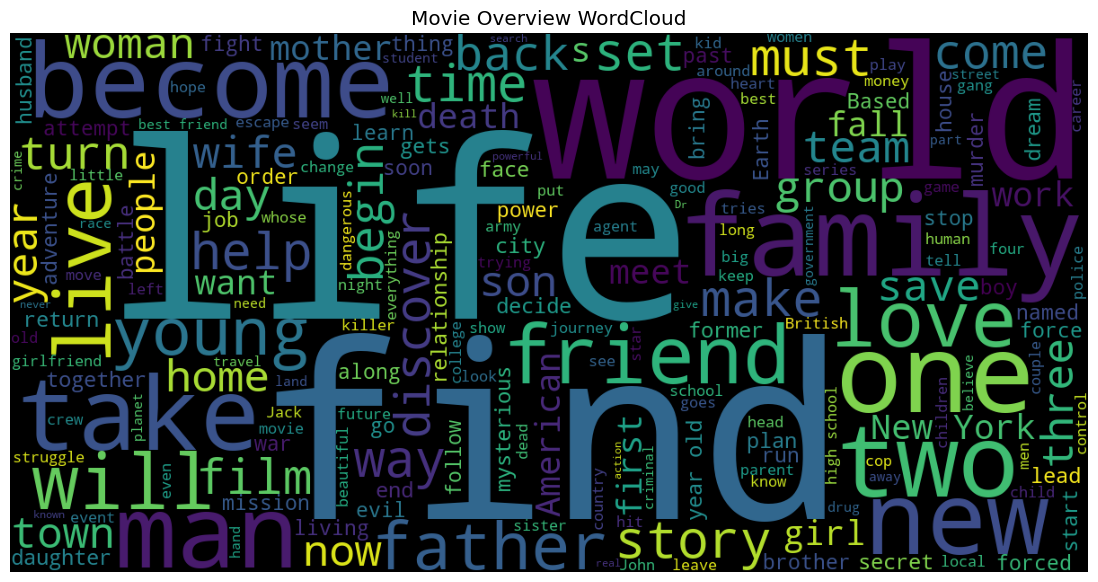

In [223]:
text = " ".join(
    movies['overview']
    .fillna('')
    .astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Movie Overview WordCloud')
plt.show()

Top Movies Languages

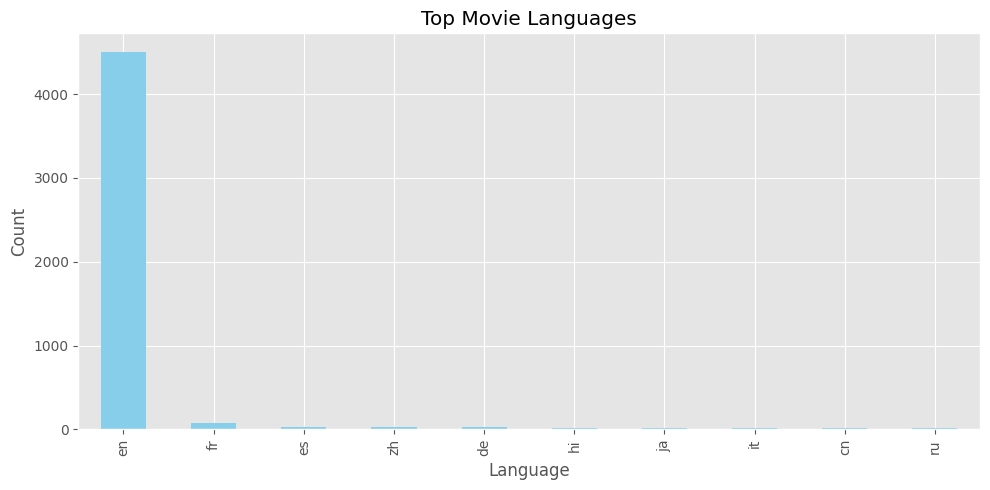

In [224]:
plt.figure(figsize=(10,5))

language_counts = movies['original_language'].fillna('Unknown').value_counts().head(10)
language_counts.plot(kind='bar', color='skyblue')

plt.title('Top Movie Languages')
plt.xlabel('Language')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Top Rated Movies

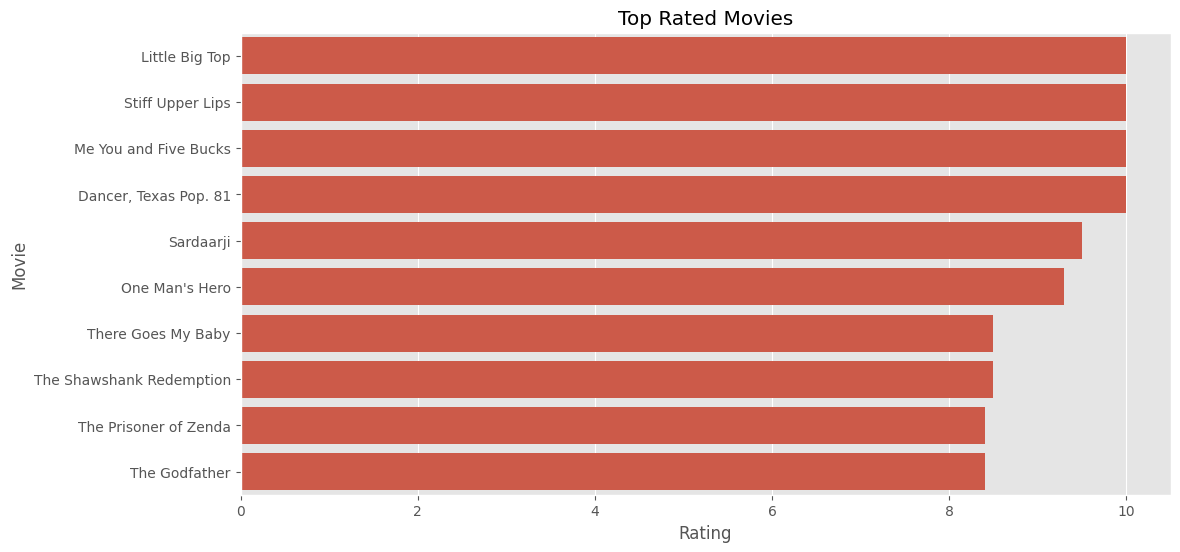

In [225]:
top_rated = movies.sort_values(
    'vote_average',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_rated['vote_average'],
    y=top_rated['title']
)

plt.title('Top Rated Movies')
plt.xlabel('Rating')
plt.ylabel('Movie')
plt.show()

Pairplot

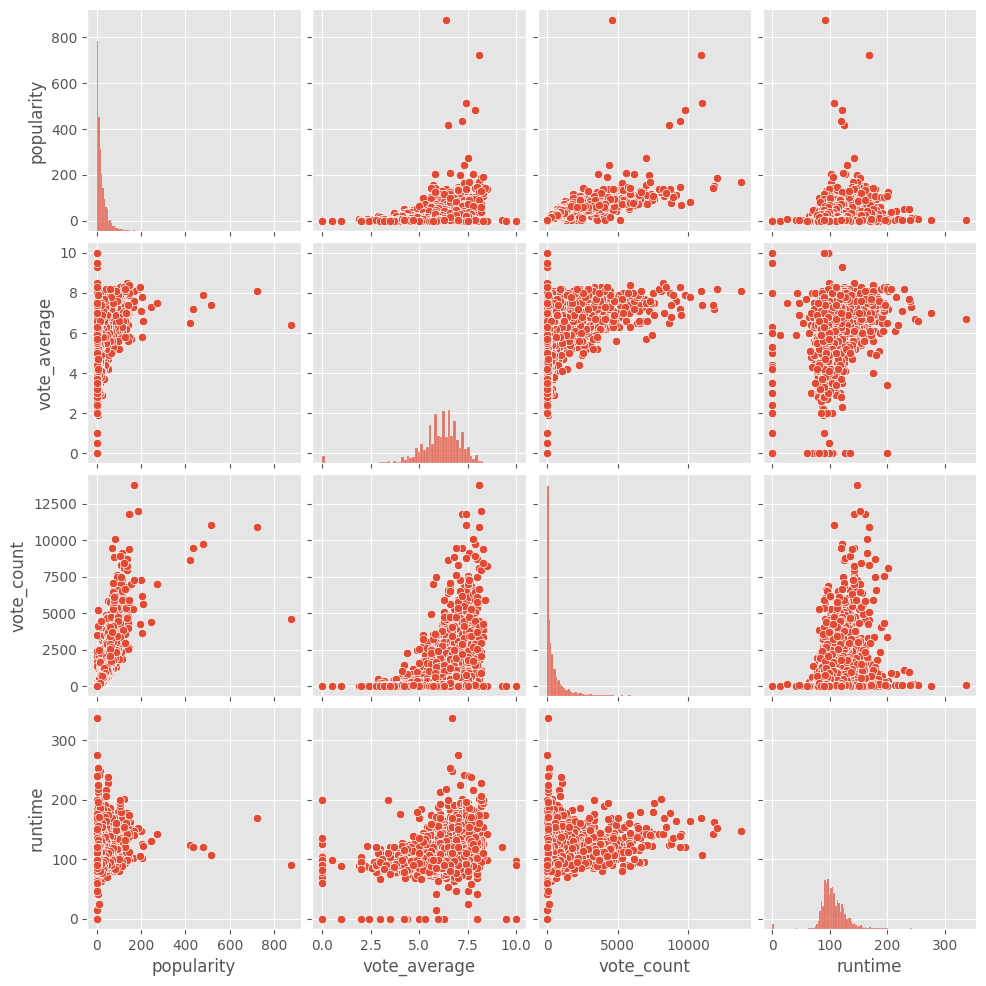

In [226]:
sns.pairplot(
    movies[
        ['popularity', 'vote_average', 'vote_count', 'runtime']
    ]
)

plt.show()

Top 10 Highest Revenue

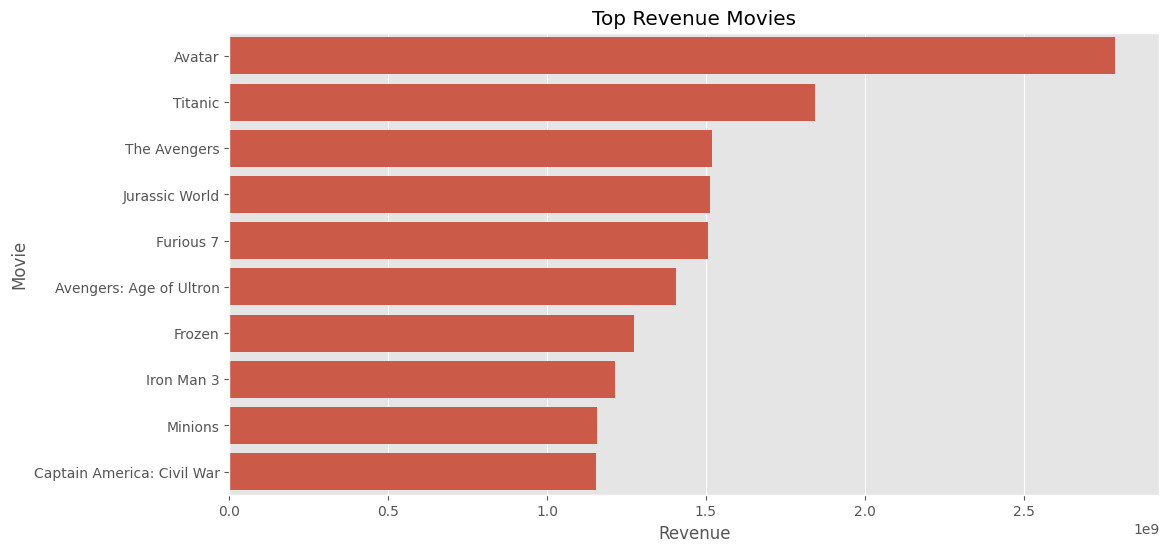

In [227]:
top_revenue = movies.sort_values(
    'revenue',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_revenue['revenue'],
    y=top_revenue['title']
)

plt.title('Top Revenue Movies')
plt.xlabel('Revenue')
plt.ylabel('Movie')
plt.show()

Average Rating by yr

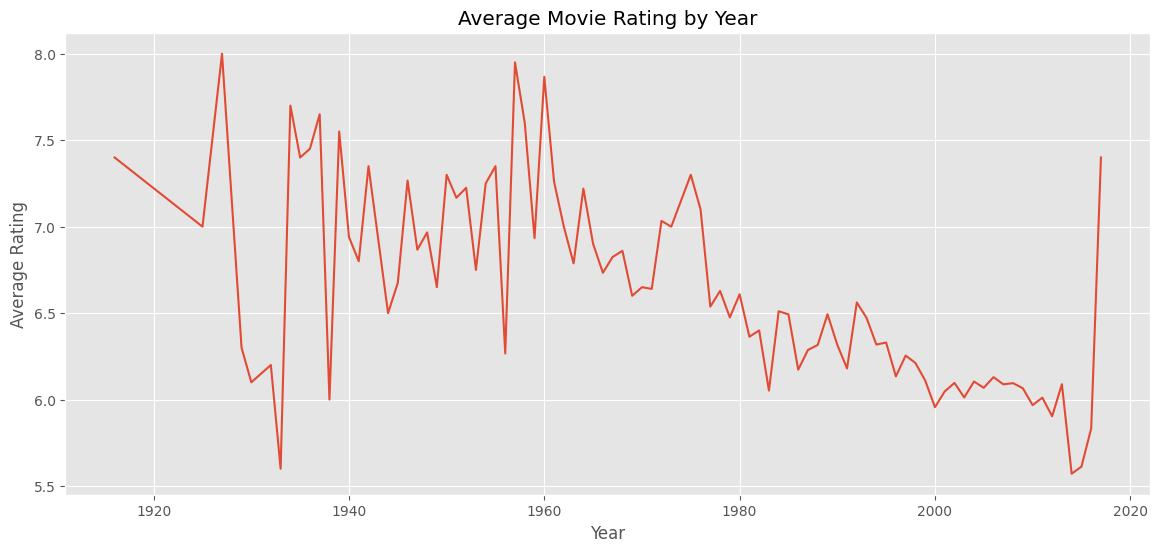

In [228]:
avg_rating_year = movies.groupby('year')[
    'vote_average'
].mean()

plt.figure(figsize=(14,6))

avg_rating_year.plot()

plt.title('Average Movie Rating by Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

Popularity vs Revenue

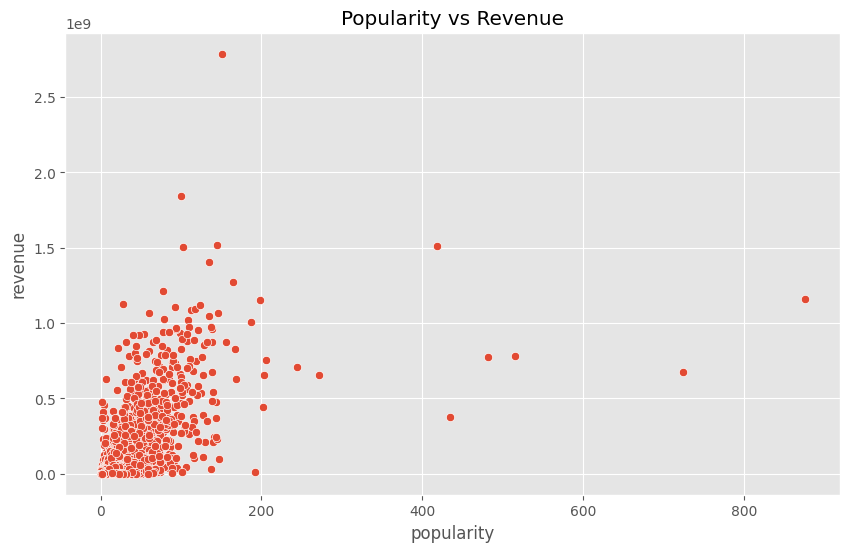

In [229]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='popularity',
    y='revenue',
    data=movies
)

plt.title('Popularity vs Revenue')
plt.show()

Runtime vs Rating

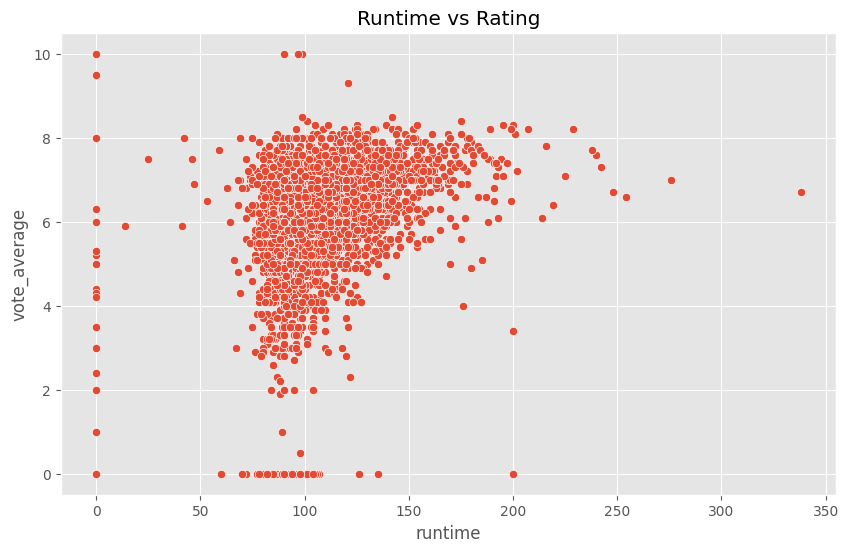

In [230]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='runtime',
    y='vote_average',
    data=movies
)

plt.title('Runtime vs Rating')
plt.show()

Top 15 Most Voted Movies

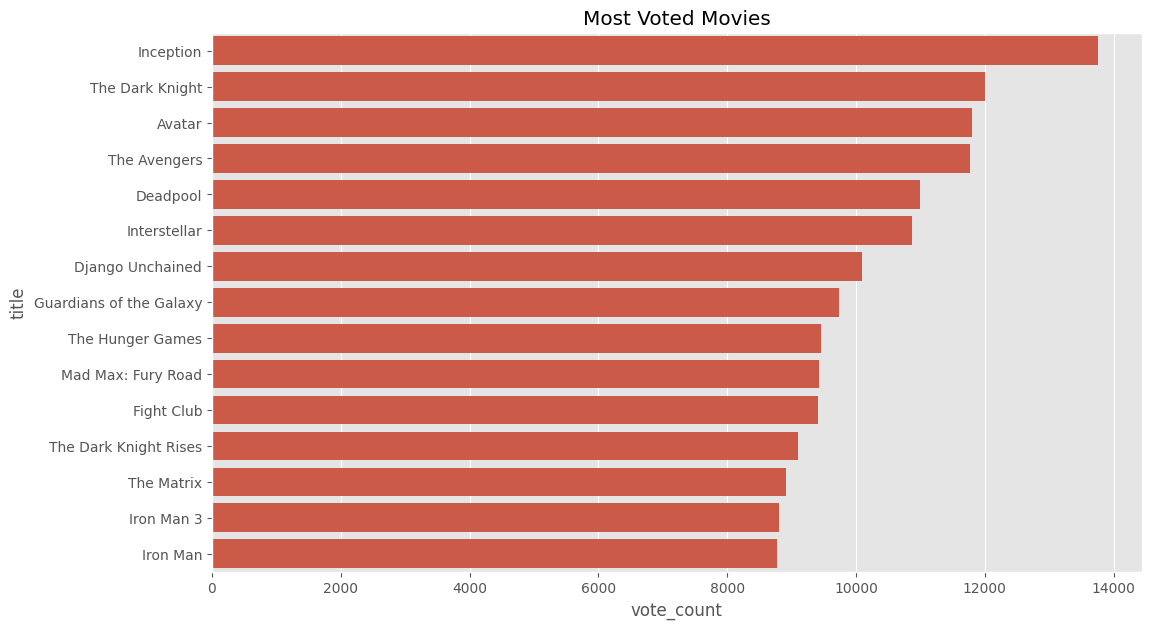

In [231]:
most_voted = movies.sort_values(
    'vote_count',
    ascending=False
).head(15)

plt.figure(figsize=(12,7))

sns.barplot(
    x=most_voted['vote_count'],
    y=most_voted['title']
)

plt.title('Most Voted Movies')
plt.show()

## Model

In [232]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.stem.porter import PorterStemmer

In [233]:
# download nltk resources
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\malsh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [234]:
## Merge everything into a single feature
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
movies.dropna(inplace=True)

In [239]:
movies['crew'] = movies['crew'].fillna('[]') ## Handle missing crew data

In [252]:
cols = ['genres','keywords','cast','crew']

for col in cols:
    movies[col] = movies[col].fillna('[]')

Convert JSON-strings into lists --> helper function

In [253]:
import ast

def fetch_director(text):
    L = []
    try:
        for i in ast.literal_eval(text):
            if i.get('job') == 'Director':
                L.append(i.get('name'))
    except:
        return []
    return L

In [254]:
movies['cast'] = movies['cast'].fillna('[]')
movies['genres'] = movies['genres'].fillna('[]')
movies['keywords'] = movies['keywords'].fillna('[]')
movies['crew'] = movies['crew'].fillna('[]')


In [255]:
movies['crew'] = movies['crew'].apply(fetch_director)

In [256]:
import ast

def convert(text):
    L = []
    try:
        if isinstance(text, str):
            for i in ast.literal_eval(text):
                L.append(i['name'])
    except:
        return []
    return L

In [257]:
# apply conversion to genres and keywords
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

#### feature engineering

In [258]:
# clean all text based columns
movies['cast'] = movies['cast'].fillna('[]')
movies['crew'] = movies['crew'].fillna('[]')
movies['overview'] = movies['overview'].fillna('')

In [259]:
# Convert cast to list of top 3 actors
def convert_cast(text):
    L = []
    try:
        for i in ast.literal_eval(text):
            L.append(i['name'])
            if len(L) == 3:
                break
    except:
        return []
    return L

movies['cast'] = movies['cast'].apply(convert_cast)

In [260]:
# Extract director from crew
def fetch_director(text):
    L = []
    try:
        for i in ast.literal_eval(text):
            if i.get('job') == 'Director':
                L.append(i['name'])
    except:
        return []
    return L

movies['crew'] = movies['crew'].apply(fetch_director)

Clean spacing

In [261]:
def collapse(L):
    return [i.replace(" ", "") for i in L]

movies['cast'] = movies['cast'].apply(collapse)
movies['crew'] = movies['crew'].apply(collapse)
movies['genres'] = movies['genres'].apply(collapse)
movies['keywords'] = movies['keywords'].apply(collapse)

In [262]:
# Process overview by splitting into words and removing spaces
movies['overview'] = movies['overview'].apply(lambda x: x.split())

Create final tags

In [263]:
movies['tags'] = (movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew'])

##### Create Final dataset

In [264]:
new_df = movies[['movie_id', 'title', 'tags']]

In [265]:
# create tags list into str
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))

In [266]:
# lowercase
new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())

## ML Process

In [267]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

In [268]:
# cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(vectors)

### Recommendation function

In [269]:
def recommend(movie):
    movie = movie.lower()

    index = new_df[new_df['title'].str.lower() == movie].index[0]
    distances = similarity[index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [270]:
# test
recommend("Avatar")

Beowulf
Apollo 18
Tears of the Sun
The American
Aliens vs Predator: Requiem
